# Compare score-prediction architectures

This notebook benchmarks several model families on the player-level dataset produced by `prepare_model_dataset.ipynb`:

- mean-score baseline;
- regularized linear models (Ridge and Elastic Net);
- nonlinear kernel regression (RBF SVR);
- tree ensembles (Random Forest, Extra Trees, and gradient boosting);
- a multilayer perceptron (MLP);
- a small PyTorch camera-view Transformer with attention across the 0°, 45°, and 135° views.

There are only 54 labeled performances and 336 predictors. Classical regularized models are therefore the strongest prior. The neural models are included as experiments, not because deeper automatically means better. All reported comparisons use the same repeated outer cross-validation splits, while preprocessing and hyperparameter selection occur only inside each training fold.

Accuracy and presentation are modeled separately and total score is derived from their predictions. All current negative-deduction labels are zero, so a deduction model cannot yet be learned.

In [17]:
from datetime import UTC, datetime
import json
import random
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RepeatedKFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)

## Configuration and data validation

Set `QUICK_RUN = True` while checking that the notebook works. Use `False` for the final benchmark. The full run is intentionally more expensive because every architecture is tuned independently within every outer fold.

In [19]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data/processed/model_ready"
MODEL_ROOT = PROJECT_ROOT / "data/processed/models/score_model_comparison"
FEATURES_PATH = DATA_ROOT / "features.csv"
TARGETS_PATH = DATA_ROOT / "targets.csv"

QUICK_RUN = False
RANDOM_STATE = 42
ANGLES = ("0", "45", "135")
TARGET_COLUMNS = ("score_accuracy", "score_presentation")
TARGET_BOUNDS = {"score_accuracy": (0.0, 4.0), "score_presentation": (0.0, 6.0)}
OUTER_SPLITS = 5
OUTER_REPEATS = 1 if QUICK_RUN else 2
INNER_SPLITS = 3

features = pd.read_csv(FEATURES_PATH)
targets = pd.read_csv(TARGETS_PATH)
assert features["player_id"].is_unique and targets["player_id"].is_unique
assert set(features["player_id"]) == set(targets["player_id"])
assert targets["score_negative"].eq(0).all(), (
    "Negative deductions now exist; add a deduction model before deriving total score."
)

dataset = features.merge(targets, on="player_id", validate="one_to_one")
suffixes_by_angle = {
    angle: sorted(
        column.removeprefix(f"view_{angle}_")
        for column in features.columns
        if column.startswith(f"view_{angle}_")
    )
    for angle in ANGLES
}
assert all(suffixes_by_angle[angle] == suffixes_by_angle[ANGLES[0]] for angle in ANGLES)
VIEW_FEATURE_SUFFIXES = suffixes_by_angle[ANGLES[0]]
FEATURE_COLUMNS = [f"view_{angle}_{suffix}" for angle in ANGLES for suffix in VIEW_FEATURE_SUFFIXES]
assert set(FEATURE_COLUMNS) == set(features.columns) - {"player_id"}

# Angle-major ordering is required by the attention model: 3 views × 112 features.
X = dataset[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
assert not X.isna().all(axis=0).any()

print(f"Players: {len(dataset)}")
print(f"Views: {len(ANGLES)}")
print(f"Features per view: {len(VIEW_FEATURE_SUFFIXES)}")
print(f"Total features: {X.shape[1]}")
print(f"Missing feature cells: {X.isna().mean().mean():.1%}")
print(f"PyTorch available: {TORCH_AVAILABLE}")
display(dataset[["player_id", *TARGET_COLUMNS, "score_total"]].head())
display(dataset[[*TARGET_COLUMNS, "score_total"]].describe().round(3))

Players: 54
Views: 3
Features per view: 112
Total features: 336
Missing feature cells: 5.8%
PyTorch available: True


,player_id,score_accuracy,score_presentation,score_total
0,WP1,3.13,4.60,7.73
1,WP2,2.90,4.30,7.20
2,WP3,3.00,4.60,7.60
3,WP4,3.03,4.43,7.46
4,WP5,2.83,4.36,7.19


,score_accuracy,score_presentation,score_total
count,54.000,54.000,54.000
mean,3.007,4.439,7.446
std,0.112,0.164,0.268
min,2.760,4.030,6.860
25%,2.930,4.330,7.230
50%,3.030,4.460,7.475
75%,3.060,4.530,7.600
max,3.200,4.800,7.960


## Camera-view Transformer regressor

The 336 columns are reshaped into three tokens, one per camera. A shared projection maps each 112-feature view to a small embedding. Learned camera embeddings identify the view, a Transformer encoder exchanges information between views, and attention pooling learns how much each view should contribute.

This is deliberately tiny and heavily regularized. A conventional sequence Transformer over video frames would require frame-level aligned inputs and substantially more labeled performances; the current table contains only player-level summaries.

In [20]:
if TORCH_AVAILABLE:
    class CameraViewAttentionNet(nn.Module):
        def __init__(self, features_per_view, d_model=16, nhead=2, dropout=0.25):
            super().__init__()
            self.view_projection = nn.Sequential(
                nn.Linear(features_per_view, d_model), nn.GELU(), nn.LayerNorm(d_model)
            )
            self.view_embedding = nn.Parameter(torch.zeros(1, len(ANGLES), d_model))
            layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 2,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
            self.encoder = nn.TransformerEncoder(layer, num_layers=1)
            self.pool_score = nn.Linear(d_model, 1)
            self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(dropout), nn.Linear(d_model, 1))

        def forward(self, x):
            tokens = self.view_projection(x) + self.view_embedding
            encoded = self.encoder(tokens)
            weights = torch.softmax(self.pool_score(encoded).squeeze(-1), dim=1)
            pooled = torch.sum(encoded * weights.unsqueeze(-1), dim=1)
            return self.head(pooled).squeeze(-1)


    class CameraViewAttentionRegressor(RegressorMixin, BaseEstimator):
        def __init__(
            self,
            n_views=3,
            d_model=16,
            nhead=2,
            dropout=0.25,
            learning_rate=1e-3,
            weight_decay=1e-3,
            epochs=250,
            batch_size=16,
            patience=30,
            random_state=42,
            device="auto",
        ):
            self.n_views = n_views
            self.d_model = d_model
            self.nhead = nhead
            self.dropout = dropout
            self.learning_rate = learning_rate
            self.weight_decay = weight_decay
            self.epochs = epochs
            self.batch_size = batch_size
            self.patience = patience
            self.random_state = random_state
            self.device = device

        def _seed(self):
            random.seed(self.random_state)
            np.random.seed(self.random_state)
            torch.manual_seed(self.random_state)

        def _device(self):
            if self.device == "auto":
                return torch.device("cuda" if torch.cuda.is_available() else "cpu")
            return torch.device(self.device)

        def fit(self, X, y):
            self._seed()
            X_array = np.asarray(X, dtype=np.float32)
            y_array = np.asarray(y, dtype=np.float32)
            if X_array.shape[1] % self.n_views:
                raise ValueError("Feature count must be divisible by n_views.")
            self.n_features_in_ = X_array.shape[1]
            self.features_per_view_ = X_array.shape[1] // self.n_views
            X_array = X_array.reshape(-1, self.n_views, self.features_per_view_)
            self.y_mean_ = float(y_array.mean())
            self.y_scale_ = float(y_array.std()) or 1.0
            y_scaled = (y_array - self.y_mean_) / self.y_scale_

            rng = np.random.default_rng(self.random_state)
            indices = rng.permutation(len(X_array))
            validation_size = max(2, int(round(0.2 * len(indices))))
            validation_index, train_index = indices[:validation_size], indices[validation_size:]
            device = self._device()
            self.model_ = CameraViewAttentionNet(
                self.features_per_view_, self.d_model, self.nhead, self.dropout
            ).to(device)
            optimizer = torch.optim.AdamW(
                self.model_.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay
            )
            loss_function = nn.SmoothL1Loss()
            train_data = TensorDataset(
                torch.from_numpy(X_array[train_index]), torch.from_numpy(y_scaled[train_index])
            )
            generator = torch.Generator().manual_seed(self.random_state)
            loader = DataLoader(
                train_data,
                batch_size=min(self.batch_size, len(train_data)),
                shuffle=True,
                generator=generator,
            )
            validation_x = torch.from_numpy(X_array[validation_index]).to(device)
            validation_y = torch.from_numpy(y_scaled[validation_index]).to(device)
            best_loss, best_state, stale_epochs = np.inf, None, 0

            for _ in range(self.epochs):
                self.model_.train()
                for batch_x, batch_y in loader:
                    optimizer.zero_grad(set_to_none=True)
                    loss = loss_function(self.model_(batch_x.to(device)), batch_y.to(device))
                    loss.backward()
                    optimizer.step()
                self.model_.eval()
                with torch.no_grad():
                    validation_loss = float(loss_function(self.model_(validation_x), validation_y))
                if validation_loss < best_loss - 1e-5:
                    best_loss = validation_loss
                    best_state = {key: value.detach().cpu().clone() for key, value in self.model_.state_dict().items()}
                    stale_epochs = 0
                else:
                    stale_epochs += 1
                    if stale_epochs >= self.patience:
                        break
            self.model_.load_state_dict(best_state)
            self.model_.to("cpu").eval()
            return self

        def predict(self, X):
            X_array = np.asarray(X, dtype=np.float32)
            X_array = X_array.reshape(-1, self.n_views, self.features_per_view_)
            with torch.no_grad():
                prediction = self.model_(torch.from_numpy(X_array)).numpy()
            return prediction * self.y_scale_ + self.y_mean_

## Model registry

Every model is wrapped in its own leakage-safe pipeline. Linear, kernel, and MLP models use feature selection because predictors greatly outnumber players. Tree ensembles use median imputation without scaling. The attention model preserves all three equal-sized camera tokens.

The grids are deliberately small. Broad searches on 54 observations increase selection noise and do not create information.

In [21]:
def selected_scaled_pipeline(regressor, add_indicator=True):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=add_indicator)),
            ("variance", VarianceThreshold()),
            ("scaler", StandardScaler()),
            ("selector", SelectKBest(score_func=f_regression)),
            ("regressor", regressor),
        ]
    )

def tree_pipeline(regressor):
    return Pipeline(
        [("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("regressor", regressor)]
    )

MODEL_SPECS = {
    "mean_baseline": {
        "estimator": Pipeline([("imputer", SimpleImputer(strategy="median")), ("regressor", DummyRegressor())]),
        "grid": {"regressor__strategy": ["mean"]},
    },
    "ridge": {
        "estimator": selected_scaled_pipeline(Ridge()),
        "grid": {
            "selector__k": [25, 50, 100, "all"],
            "regressor__alpha": [1.0, 10.0, 100.0, 1000.0],
        },
    },
    "elastic_net": {
        "estimator": selected_scaled_pipeline(ElasticNet(max_iter=10000, random_state=RANDOM_STATE)),
        "grid": {
            "selector__k": [25, 50, 100],
            "regressor__alpha": [0.01, 0.1],
            "regressor__l1_ratio": [0.1, 0.7],
        },
    },
    "rbf_svr": {
        "estimator": selected_scaled_pipeline(SVR(kernel="rbf")),
        "grid": {
            "selector__k": [25, 50, 100],
            "regressor__C": [0.1, 1.0],
            "regressor__epsilon": [0.02, 0.1],
            "regressor__gamma": ["scale"],
        },
    },
    "random_forest": {
        "estimator": tree_pipeline(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1)),
        "grid": {
            "regressor__max_depth": [2, None],
            "regressor__min_samples_leaf": [2, 6],
            "regressor__max_features": [0.3, 0.7],
        },
    },
    "extra_trees": {
        "estimator": tree_pipeline(ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1)),
        "grid": {
            "regressor__max_depth": [2, None],
            "regressor__min_samples_leaf": [2, 6],
            "regressor__max_features": [0.3, 0.7],
        },
    },
    "hist_gradient_boosting": {
        "estimator": tree_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
        "grid": {
            "regressor__learning_rate": [0.03, 0.1],
            "regressor__max_iter": [100, 250],
            "regressor__max_leaf_nodes": [3, 7],
            "regressor__l2_regularization": [0.0, 1.0],
        },
    },
    "mlp": {
        "estimator": selected_scaled_pipeline(
            MLPRegressor(early_stopping=True, max_iter=1500, validation_fraction=0.2, random_state=RANDOM_STATE)
        ),
        "grid": {
            "selector__k": [25, 50, 100],
            "regressor__hidden_layer_sizes": [(16,), (32, 16)],
            "regressor__alpha": [0.1, 1.0],
            "regressor__learning_rate_init": [0.001],
        },
    },
}

if TORCH_AVAILABLE:
    MODEL_SPECS["camera_attention"] = {
        "estimator": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
                ("scaler", StandardScaler()),
                ("regressor", CameraViewAttentionRegressor(random_state=RANDOM_STATE, device="auto")),
            ]
        ),
        "grid": {
            "regressor__d_model": [8, 16],
            "regressor__nhead": [2],
            "regressor__dropout": [0.3],
            "regressor__weight_decay": [0.01],
            "regressor__epochs": [100 if QUICK_RUN else 300],
        },
    }

if QUICK_RUN:
    for specification in MODEL_SPECS.values():
        specification["grid"] = {key: [values[0]] for key, values in specification["grid"].items()}

display(pd.DataFrame({name: {"grid_combinations": int(np.prod([len(v) for v in spec["grid"].values()]))} for name, spec in MODEL_SPECS.items()}).T)

,grid_combinations
mean_baseline,1
ridge,16
elastic_net,12
rbf_svr,12
random_forest,8
extra_trees,8
hist_gradient_boosting,16
mlp,12
camera_attention,2


## Fair nested benchmark

All models receive identical outer train/test indices. Each model performs its own inner search using training players only. Predictions are clipped to the valid component range. This cell can take time during a full run, especially for the attention model.

In [22]:
outer_cv = list(
    RepeatedKFold(
        n_splits=OUTER_SPLITS,
        n_repeats=OUTER_REPEATS,
        random_state=RANDOM_STATE,
    ).split(X)
)

prediction_rows, tuning_rows = [], []
for target_name in TARGET_COLUMNS:
    y = dataset[target_name]
    lower, upper = TARGET_BOUNDS[target_name]
    for model_name, specification in MODEL_SPECS.items():
        print(f"Evaluating {target_name} / {model_name}")
        for outer_index, (train_index, test_index) in enumerate(outer_cv, start=1):
            repeat = (outer_index - 1) // OUTER_SPLITS + 1
            fold = (outer_index - 1) % OUTER_SPLITS + 1
            inner_cv = KFold(
                n_splits=INNER_SPLITS,
                shuffle=True,
                random_state=RANDOM_STATE + outer_index,
            )
            search = GridSearchCV(
                estimator=specification["estimator"],
                param_grid=specification["grid"],
                scoring="neg_mean_absolute_error",
                cv=inner_cv,
                n_jobs=1 if model_name == "camera_attention" else -1,
                refit=True,
                error_score="raise",
            )
            search.fit(X.iloc[train_index], y.iloc[train_index])
            predictions = np.clip(search.predict(X.iloc[test_index]), lower, upper)
            for row_index, prediction in zip(test_index, predictions):
                prediction_rows.append(
                    {
                        "player_id": dataset["player_id"].iloc[row_index],
                        "target": target_name,
                        "model": model_name,
                        "repeat": repeat,
                        "fold": fold,
                        "actual": float(y.iloc[row_index]),
                        "prediction": float(prediction),
                    }
                )
            tuning_rows.append(
                {
                    "target": target_name,
                    "model": model_name,
                    "repeat": repeat,
                    "fold": fold,
                    "inner_cv_mae": float(-search.best_score_),
                    "best_params": json.dumps(search.best_params_, sort_keys=True),
                }
            )

repeated_predictions = pd.DataFrame(prediction_rows)
tuning_history = pd.DataFrame(tuning_rows)
print(f"Completed {len(tuning_history)} nested model fits.")

Evaluating score_accuracy / mean_baseline
Evaluating score_accuracy / ridge
Evaluating score_accuracy / elastic_net
Evaluating score_accuracy / rbf_svr
Evaluating score_accuracy / random_forest
Evaluating score_accuracy / extra_trees
Evaluating score_accuracy / hist_gradient_boosting
Evaluating score_accuracy / mlp
Evaluating score_accuracy / camera_attention


/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Deskt

Evaluating score_presentation / mean_baseline
Evaluating score_presentation / ridge
Evaluating score_presentation / elastic_net
Evaluating score_presentation / rbf_svr
Evaluating score_presentation / random_forest
Evaluating score_presentation / extra_trees
Evaluating score_presentation / hist_gradient_boosting
Evaluating score_presentation / mlp
Evaluating score_presentation / camera_attention


/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Deskt

Completed 180 nested model fits.


## Rank architectures using out-of-fold predictions

Predictions are averaged over repeats for each player before metrics are calculated. MAE is the primary ranking metric because it is directly interpretable in score points. The baseline must remain in the table: a complex model that cannot beat it is not useful.

In [23]:
component_oof = (
    repeated_predictions.groupby(["player_id", "target", "model"], as_index=False)
    .agg(actual=("actual", "first"), prediction=("prediction", "mean"), prediction_sd=("prediction", "std"))
)

def metrics(actual, predicted):
    return pd.Series(
        {
            "mae": mean_absolute_error(actual, predicted),
            "rmse": np.sqrt(mean_squared_error(actual, predicted)),
            "r2": r2_score(actual, predicted),
        }
    )

component_metrics = (
    component_oof.groupby(["target", "model"], observed=True)
    .apply(lambda group: metrics(group["actual"], group["prediction"]), include_groups=False)
    .reset_index()
)

wide = component_oof.pivot(index="player_id", columns=["model", "target"], values=["actual", "prediction"])
total_rows = []
for model_name in MODEL_SPECS:
    actual_total = (
        wide[("actual", model_name, "score_accuracy")]
        + wide[("actual", model_name, "score_presentation")]
    )
    predicted_total = (
        wide[("prediction", model_name, "score_accuracy")]
        + wide[("prediction", model_name, "score_presentation")]
    )
    row = {"target": "score_total", "model": model_name}
    row.update(metrics(actual_total, predicted_total).to_dict())
    total_rows.append(row)

model_metrics = pd.concat([component_metrics, pd.DataFrame(total_rows)], ignore_index=True)
model_metrics["mae_rank"] = model_metrics.groupby("target")["mae"].rank(method="min")
model_ranking = (
    model_metrics.groupby("model", as_index=False)
    .agg(mean_mae_rank=("mae_rank", "mean"), mean_target_mae=("mae", "mean"))
    .sort_values(["mean_mae_rank", "mean_target_mae"])
)
display(model_metrics.sort_values(["target", "mae"]).round(4))
display(model_ranking.round(4))

,target,model,mae,rmse,r2,mae_rank
4,score_accuracy,mean_baseline,0.0922,0.1147,-0.0609,1.0
3,score_accuracy,hist_gradient_boosting,0.0935,0.1176,-0.1146,2.0
7,score_accuracy,rbf_svr,0.0952,0.1206,-0.1723,3.0
2,score_accuracy,extra_trees,0.0957,0.1185,-0.1324,4.0
6,score_accuracy,random_forest,0.0973,0.1199,-0.1593,5.0
0,score_accuracy,camera_attention,0.1019,0.1248,-0.2555,6.0
1,score_accuracy,elastic_net,0.1046,0.1453,-0.7036,7.0
8,score_accuracy,ridge,0.1074,0.1455,-0.7067,8.0
5,score_accuracy,mlp,0.4343,0.5773,-25.8779,9.0
13,score_presentation,mean_baseline,0.1329,0.1662,-0.0480,1.0


,model,mean_mae_rank,mean_target_mae
4,mean_baseline,1.0000,0.1482
3,hist_gradient_boosting,2.0000,0.1505
6,random_forest,3.6667,0.1558
2,extra_trees,4.0000,0.1558
7,rbf_svr,4.3333,0.1575
1,elastic_net,6.3333,0.1630
8,ridge,7.3333,0.1657
0,camera_attention,7.3333,0.1690
5,mlp,9.0000,0.6342


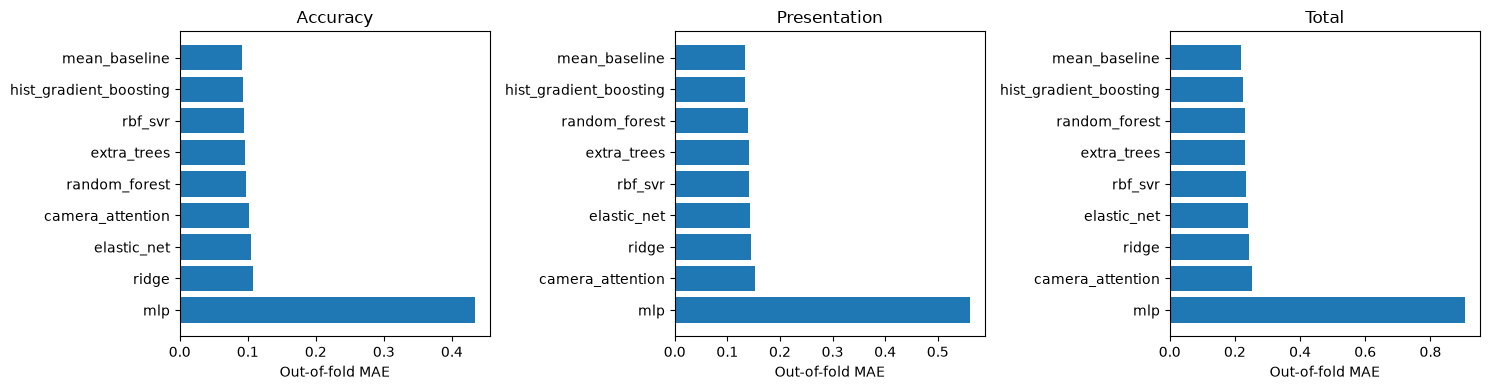

Best total-score architecture: mean_baseline


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for axis, target_name in zip(axes, (*TARGET_COLUMNS, "score_total")):
    plot_data = model_metrics.loc[model_metrics["target"].eq(target_name)].sort_values("mae")
    axis.barh(plot_data["model"], plot_data["mae"])
    axis.invert_yaxis()
    axis.set_title(target_name.replace("score_", "").title())
    axis.set_xlabel("Out-of-fold MAE")
plt.tight_layout()
plt.show()

best_total_model = (
    model_metrics.loc[model_metrics["target"].eq("score_total")]
    .sort_values("mae").iloc[0]["model"]
)
print(f"Best total-score architecture: {best_total_model}")

## Refit every architecture and save the comparison

Each architecture is tuned once more using all labeled players and stored for later analysis. The recommended deployment model is selected by mean rank across accuracy, presentation, and total MAE. Training predictions are not used for model selection.

In [25]:
final_models, final_search_rows = {}, []
final_cv = RepeatedKFold(
    n_splits=OUTER_SPLITS,
    n_repeats=1 if QUICK_RUN else 2,
    random_state=RANDOM_STATE,
)
for model_name, specification in MODEL_SPECS.items():
    final_models[model_name] = {}
    for target_name in TARGET_COLUMNS:
        print(f"Refitting {model_name} / {target_name}")
        search = GridSearchCV(
            specification["estimator"],
            specification["grid"],
            scoring="neg_mean_absolute_error",
            cv=final_cv,
            n_jobs=1 if model_name == "camera_attention" else -1,
            refit=True,
            error_score="raise",
        )
        search.fit(X, dataset[target_name])
        final_models[model_name][target_name] = search.best_estimator_
        final_search_rows.append(
            {
                "model": model_name,
                "target": target_name,
                "cv_mae": float(-search.best_score_),
                "best_params": json.dumps(search.best_params_, sort_keys=True),
            }
        )

final_search_results = pd.DataFrame(final_search_rows)
recommended_model = model_ranking.iloc[0]["model"]
print(f"Recommended model from nested CV: {recommended_model}")
display(final_search_results.round(4))

Refitting mean_baseline / score_accuracy
Refitting mean_baseline / score_presentation
Refitting ridge / score_accuracy
Refitting ridge / score_presentation
Refitting elastic_net / score_accuracy
Refitting elastic_net / score_presentation
Refitting rbf_svr / score_accuracy
Refitting rbf_svr / score_presentation
Refitting random_forest / score_accuracy
Refitting random_forest / score_presentation
Refitting extra_trees / score_accuracy
Refitting extra_trees / score_presentation
Refitting hist_gradient_boosting / score_accuracy
Refitting hist_gradient_boosting / score_presentation
Refitting mlp / score_accuracy
Refitting mlp / score_presentation
Refitting camera_attention / score_accuracy


/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Deskt

Refitting camera_attention / score_presentation


/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Desktop/national-cart-ocr/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/nazi/Deskt

Recommended model from nested CV: mean_baseline


,model,target,cv_mae,best_params
0,mean_baseline,score_accuracy,0.0923,"{""regressor__strategy"": ""mean""}"
1,mean_baseline,score_presentation,0.1329,"{""regressor__strategy"": ""mean""}"
2,ridge,score_accuracy,0.0951,"{""regressor__alpha"": 1000.0, ""selector__k"": 25}"
3,ridge,score_presentation,0.1342,"{""regressor__alpha"": 1000.0, ""selector__k"": 25}"
4,elastic_net,score_accuracy,0.0923,"{""regressor__alpha"": 0.1, ""regressor__l1_ratio..."
5,elastic_net,score_presentation,0.1356,"{""regressor__alpha"": 0.1, ""regressor__l1_ratio..."
6,rbf_svr,score_accuracy,0.0958,"{""regressor__C"": 1.0, ""regressor__epsilon"": 0...."
7,rbf_svr,score_presentation,0.1405,"{""regressor__C"": 0.1, ""regressor__epsilon"": 0...."
8,random_forest,score_accuracy,0.0968,"{""regressor__max_depth"": 2, ""regressor__max_fe..."
9,random_forest,score_presentation,0.1390,"{""regressor__max_depth"": 2, ""regressor__max_fe..."


In [26]:
MODEL_ROOT.mkdir(parents=True, exist_ok=True)
created_at = datetime.now(UTC).isoformat()
bundle = {
    "created_at_utc": created_at,
    "feature_columns": FEATURE_COLUMNS,
    "angles": ANGLES,
    "view_feature_suffixes": VIEW_FEATURE_SUFFIXES,
    "target_bounds": TARGET_BOUNDS,
    "models": final_models,
    "recommended_model": recommended_model,
    "total_formula": "score_accuracy + score_presentation",
    "training_players": dataset["player_id"].tolist(),
}

bundle_path = MODEL_ROOT / "score_model_comparison.joblib"
joblib.dump(bundle, bundle_path)
component_oof.to_csv(MODEL_ROOT / "out_of_fold_predictions.csv", index=False)
model_metrics.to_csv(MODEL_ROOT / "model_metrics.csv", index=False)
model_ranking.to_csv(MODEL_ROOT / "model_ranking.csv", index=False)
tuning_history.to_csv(MODEL_ROOT / "nested_tuning_history.csv", index=False)
final_search_results.to_csv(MODEL_ROOT / "final_search_results.csv", index=False)

summary = {
    "created_at_utc": created_at,
    "players": len(dataset),
    "features": len(FEATURE_COLUMNS),
    "architectures": list(MODEL_SPECS),
    "recommended_model": recommended_model,
    "quick_run": QUICK_RUN,
    "outer_cv": {"splits": OUTER_SPLITS, "repeats": OUTER_REPEATS},
    "metrics": model_metrics.round(8).to_dict(orient="records"),
    "notes": [
        "Architecture selection uses nested out-of-fold MAE.",
        "Total score equals predicted accuracy plus predicted presentation.",
        "No deduction model was fitted because every deduction label is zero.",
        "Deep-model results are exploratory with only 54 labeled performances."
    ],
}
(MODEL_ROOT / "comparison_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"Saved comparison artifacts to {MODEL_ROOT}")

Saved comparison artifacts to /home/nazi/Desktop/poomsae-scoring-system/data/processed/models/score_model_comparison


## Load the recommended model and predict

New rows must come from the same preparation pipeline. The example below verifies serialization using one existing row; it is not an unbiased test.

In [27]:
def predict_scores(new_features, model_bundle, model_name=None):
    model_name = model_name or model_bundle["recommended_model"]
    required = model_bundle["feature_columns"]
    missing = sorted(set(required) - set(new_features.columns))
    if missing:
        raise ValueError(f"Missing {len(missing)} features; first missing: {missing[:5]}")
    model_input = new_features.loc[:, required].apply(pd.to_numeric, errors="coerce")
    result = pd.DataFrame(index=new_features.index)
    for target_name, model in model_bundle["models"][model_name].items():
        lower, upper = model_bundle["target_bounds"][target_name]
        result[target_name] = np.clip(model.predict(model_input), lower, upper)
    result["score_total"] = result["score_accuracy"] + result["score_presentation"]
    return result

loaded_bundle = joblib.load(bundle_path)
example = predict_scores(features.iloc[[0]], loaded_bundle)
example.insert(0, "player_id", features.iloc[[0]]["player_id"].to_numpy())
display(example.round(3))

,player_id,score_accuracy,score_presentation,score_total
0,WP1,3.007,4.439,7.446


## How to interpret the result

Prefer the simplest model whose repeated out-of-fold MAE is consistently best. Do not select the Transformer merely because it uses attention. If several models are close, Ridge is easier to validate and deploy. If no learned architecture beats the mean baseline, the limiting factor is likely the amount or quality of labeled data and the player-level feature representation—not insufficient model complexity.

A future sequence model becomes more defensible after collecting many more scored performances and constructing aligned movement-level or frame-level sequences. At that stage, compare temporal convolution, recurrent, and Transformer encoders using competition- or athlete-grouped validation.